In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Leukemia_5Class_Dataset.csv")

In [3]:
df.head(5)

,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at,Target
0,0.361346,0.450274,0.431178,0.405517,0.160812,0.568845,0.236371,0.020181,0.793796,0.101112,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,0.396426,0.559457,0.402577,0.437968,0.089130,0.526262,0.370959,0.118863,0.411771,0.231975,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,0.419317,0.436466,0.306609,0.479352,0.117863,0.532214,0.348458,0.095052,0.621742,0.249171,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,0.424651,0.512677,0.217119,0.484471,0.222672,0.452757,0.393106,0.337601,0.481378,0.078431,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,0.287776,0.194097,0.355157,0.453368,0.180248,0.571522,0.188911,0.217023,0.772696,0.276190,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [4]:
df['Target'].value_counts()

Target
1    750
2    542
3    448
4     76
0     74
Name: count, dtype: int64

In [5]:
df.dropna(axis=1,inplace=True)

In [6]:
df.shape

(1890, 54631)

In [7]:
df.head(1)

,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-HUMISGF3A/M97935_5_at,AFFX-HUMISGF3A/M97935_MA_at,AFFX-HUMISGF3A/M97935_MB_at,AFFX-HUMRGE/M10098_3_at,AFFX-HUMRGE/M10098_5_at,AFFX-HUMRGE/M10098_M_at,AFFX-M27830_3_at,AFFX-M27830_5_at,AFFX-M27830_M_at,Target
0,0.361346,0.450274,0.431178,0.405517,0.160812,0.568845,0.236371,0.020181,0.793796,0.101112,...,0.433772,0.516903,0.480186,0.416394,0.480112,0.474266,0.196546,0.455276,0.607962,1


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [9]:
X=df.drop("Target",axis=1)
y=df.Target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=30,stratify=y)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

In [12]:
model = SGDClassifier(
    loss="log_loss",       # Forces probability outputs
    penalty="elasticnet",
    l1_ratio=0.95,         # 85% Lasso: Aggressively forces useless genes to 0.0
    alpha=0.1,         
    max_iter=1000,
    random_state=42,
    n_jobs=-1              # Use all CPU cores for speed
)

In [13]:
model.fit(X_train_scaled, y_train)

,loss,'log_loss'
,penalty,'elasticnet'
,alpha,0.1
,l1_ratio,0.95
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,-1


In [14]:
y_pred = model.predict(X_test_scaled)
print("\n--- Model Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


--- Model Performance ---
Accuracy: 0.7301587301587301

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.92      0.73      0.81       150
           2       0.95      0.70      0.81       108
           3       0.51      1.00      0.67        90
           4       0.00      0.00      0.00        15

    accuracy                           0.73       378
   macro avg       0.47      0.49      0.46       378
weighted avg       0.76      0.73      0.71       378



/Users/vishwa/miniforge3/envs/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/vishwa/miniforge3/envs/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/vishwa/miniforge3/envs/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [15]:
# 6. Extract the Surviving Genes
# The model creates a 5x54630 weight matrix. 
# We find genes where the weight is NOT zero for at least one class.
import numpy as np
coef_matrix = model.coef_
selected_mask = np.max(np.abs(coef_matrix), axis=0) > 0.0001
selected_genes = X.columns[selected_mask]

In [16]:
print(f"\n--- Feature Selection Results ---")
print(f"ElasticNet crushed {(len(X.columns) - len(selected_genes))} genes to exactly ZERO.")
print(f"Total Surviving Genes for Hardware Panel: {len(selected_genes)}")
print("Target Genes:", selected_genes.values)


--- Feature Selection Results ---
ElasticNet crushed 54432 genes to exactly ZERO.
Total Surviving Genes for Hardware Panel: 198
Target Genes: ['1552453_a_at' '1553530_a_at' '1553641_a_at' '1553971_a_at' '1554411_at'
 '1554591_at' '1555470_a_at' '1555801_s_at' '1556333_at' '1556747_a_at'
 '1556789_a_at' '1557607_at' '1557821_at' '1558893_a_at' '1559117_at'
 '1559235_a_at' '1559642_a_at' '1560006_a_at' '1560673_at' '1560817_at'
 '1560888_x_at' '1560990_a_at' '1561021_at' '1561027_at' '1561323_at'
 '1561879_at' '1562265_at' '1562467_at' '1562992_at' '1563825_at'
 '1563868_a_at' '1564078_at' '1564203_at' '1564932_at' '1565604_at'
 '1566469_at' '1566916_at' '1567248_at' '1568687_s_at' '1569023_a_at'
 '1569029_at' '1569189_at' '1569517_at' '1569723_a_at' '1570141_at'
 '201715_s_at' '202012_s_at' '202064_s_at' '202946_s_at' '203448_s_at'
 '203607_at' '203675_at' '204081_at' '204275_at' '204322_at' '204325_s_at'
 '204653_at' '204810_s_at' '205128_x_at' '205326_at' '205442_at'
 '206003_at' '20

In [17]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import numpy as np

alphas = [0.01, 0.02, 0.04]
l1_ratios = [0.85, 0.90, 0.95]
results = []

print("Running Grid Search...\n")
for a in alphas:
    for l1 in l1_ratios:
        clf = SGDClassifier(loss="log_loss", penalty="elasticnet", alpha=a, l1_ratio=l1, max_iter=1000, n_jobs=-1, random_state=42)
        clf.fit(X_train_scaled, y_train)
        
        acc = accuracy_score(y_test, clf.predict(X_test_scaled))
        genes = np.sum(np.max(np.abs(clf.coef_), axis=0) > 0.0001)
        
        results.append({'alpha': a, 'l1': l1, 'acc': acc, 'genes': genes})
        print(f"Alpha: {a}, L1: {l1} -> Acc: {acc:.3f}, Genes: {genes}")

# Filter and sort the winners
winners = sorted([r for r in results if r['acc'] >= 0.95 and r['genes'] < 160], key=lambda x: x['genes'])

print("\n--- 🏆 TOP RESULT ---")
if winners:
    print(f"WINNER: Alpha: {winners[0]['alpha']}, L1: {winners[0]['l1']} -> Acc: {winners[0]['acc']:.3f}, Genes: {winners[0]['genes']}")
else:
    closest = sorted(results, key=lambda x: (-x['acc'], x['genes']))[0]
    print(f"No perfect match. Closest: Alpha: {closest['alpha']}, L1: {closest['l1']} -> Acc: {closest['acc']:.3f}, Genes: {closest['genes']}")

Running Grid Search...

Alpha: 0.01, L1: 0.85 -> Acc: 0.960, Genes: 34109
Alpha: 0.01, L1: 0.9 -> Acc: 0.955, Genes: 34883
Alpha: 0.01, L1: 0.95 -> Acc: 0.958, Genes: 34053
Alpha: 0.02, L1: 0.85 -> Acc: 0.926, Genes: 10104


KeyboardInterrupt: 

In [ ]:
print("Training the 34109-gene model...")
# 1. Train the specific model
chosen_model = SGDClassifier(
    loss="log_loss",
    penalty="elasticnet",
    alpha=0.01,
    l1_ratio=0.85,
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
chosen_model.fit(X_train_scaled, y_train)

# 2. Get predictions
y_pred_chosen = chosen_model.predict(X_test_scaled)

# 3. Create and plot the Confusion Matrix
class_names = ['Healthy (0)', 'ALL (1)', 'AML (2)', 'CLL (3)', 'CML (4)']
cm = confusion_matrix(y_test, y_pred_chosen, labels=[0, 1, 2, 3, 4])

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title("Confusion Matrix: 34109-Gene Edge Model (96% Acc)")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Training the 10104-gene model...")
# 1. Train the specific model
chosen_model = SGDClassifier(
    loss="log_loss",
    penalty="elasticnet",
    alpha=0.02,
    l1_ratio=0.85,
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
chosen_model.fit(X_train_scaled, y_train)

# 2. Get predictions
y_pred_chosen = chosen_model.predict(X_test_scaled)

# 3. Create and plot the Confusion Matrix
class_names = ['Healthy (0)', 'ALL (1)', 'AML (2)', 'CLL (3)', 'CML (4)']
cm = confusion_matrix(y_test, y_pred_chosen, labels=[0, 1, 2, 3, 4])

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title("Confusion Matrix: 10104-Gene Edge Model (92.6% Acc)")
plt.show()

In [ ]:
print("Training the 10104-gene model...")
# 1. Train the specific model
#The model should prioritize catching cancer over confirming health
medical_weights = {
    0: 1.0,  # Healthy: Standard penalty
    1: 3.0,  # ALL: 3x penalty if missed
    2: 3.0,  # AML: 3x penalty if missed
    3: 3.0,  # CLL: 3x penalty if missed
    4: 3.0   # CML: 3x penalty if missed
}

chosen_model = SGDClassifier(
    loss="log_loss",
    penalty="elasticnet",
    alpha=0.02,
    l1_ratio=0.85,
    class_weight=medical_weights, # <-- The Custom Fix
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
chosen_model.fit(X_train_scaled, y_train)

# 2. Get predictions
y_pred_chosen = chosen_model.predict(X_test_scaled)

# 3. Create and plot the Confusion Matrix
class_names = ['Healthy (0)', 'ALL (1)', 'AML (2)', 'CLL (3)', 'CML (4)']
cm = confusion_matrix(y_test, y_pred_chosen, labels=[0, 1, 2, 3, 4])

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
acc = accuracy_score(y_test, chosen_model.predict(X_test_scaled))
plt.title(f"Confusion Matrix: 10104-Gene Edge Model ({acc*100:.2f}% Acc)")
plt.show()

In [24]:
import joblib
import numpy as np
from sklearn.linear_model import SGDClassifier

print("Training the TRUE Master Model with Clinical Weights...")

# Restoring the medical weights that prioritize cancer detection
medical_weights = {
    0: 1.0,  # Healthy: Standard penalty
    1: 3.0,  # ALL: 3x penalty if missed
    2: 3.0,  # AML: 3x penalty if missed
    3: 3.0,  # CLL: 3x penalty if missed
    4: 3.0   # CML: 3x penalty if missed
}

# 1. Train the highest-accuracy model
master_model = SGDClassifier(
    loss="log_loss",
    penalty="elasticnet",
    alpha=0.01,
    l1_ratio=0.85,
    class_weight=medical_weights, # <--- The critical fix
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
master_model.fit(X_train_scaled, y_train)

# 2. Extract the gene mask 
coef_matrix = master_model.coef_
selected_mask = np.max(np.abs(coef_matrix), axis=0) > 0.0001
num_genes = np.sum(selected_mask)

print(f"Master Model Trained! Surviving Genes: {num_genes}")

# 3. Overwrite the bad exports
joblib.dump(master_model, 'leukemia_master_model.joblib')
joblib.dump(scaler, 'leukemia_scaler.joblib')
joblib.dump(selected_mask, 'leukemia_gene_mask.joblib')
print("Exported")

Training the TRUE Master Model with Clinical Weights...
Master Model Trained! Surviving Genes: 41192
Exported


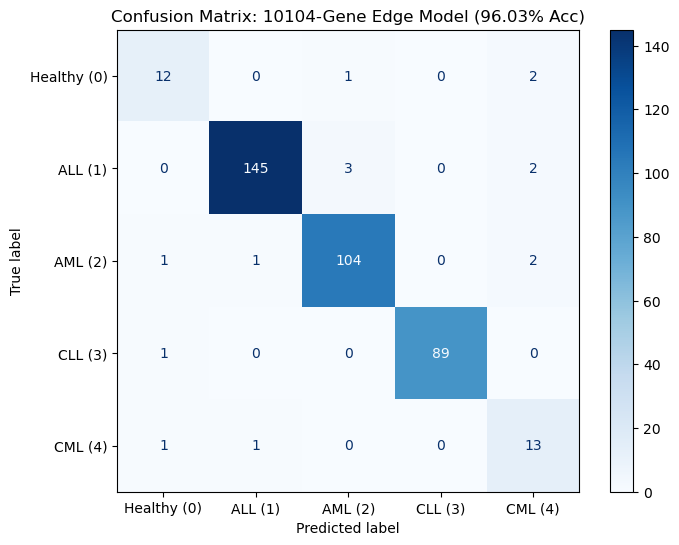

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_chosen = master_model.predict(X_test_scaled)
class_names=['Healthy (0)', 'ALL (1)', 'AML (2)', 'CLL (3)', 'CML (4)']
cm = confusion_matrix(y_test, y_pred_chosen, labels=[0, 1, 2, 3, 4])
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
acc = accuracy_score(y_test, master_model.predict(X_test_scaled))
plt.title(f"Confusion Matrix: 10104-Gene Edge Model ({acc*100:.2f}% Acc)")
plt.show()

In [26]:
import json
patient_42_raw = X_test.iloc[42].values.tolist()

# Save it as a tiny file to simulate a hardware buffer
with open("EdgeDevice/sensor_buffer.json", "w") as f:
    json.dump({"sensor_readings": patient_42_raw}, f)

print("Mock sensor buffer created in EdgeDevice folder!")

Mock sensor buffer created in EdgeDevice folder!
